In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('turmas_com_clusters.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125793 entries, 0 to 125792
Data columns (total 9 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   id_turma                    125793 non-null  int64  
 1   qtd_discentes               125793 non-null  int64  
 2   proporcao_aprovados         125793 non-null  float64
 3   media_final_geral           125793 non-null  float64
 4   postura_profissional_media  125793 non-null  float64
 5   postura_profissional_DP     125793 non-null  float64
 6   atuacao_profissional_media  125793 non-null  float64
 7   atuacao_profissional_DP     125793 non-null  float64
 8   cluster                     125793 non-null  int64  
dtypes: float64(6), int64(3)
memory usage: 8.6 MB


In [4]:
df_detalhado = pd.read_csv('perfil_detalhado_clusters.csv')
df_detalhado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  64 non-null     object 
 1   Unnamed: 1  64 non-null     object 
 2   0           64 non-null     float64
 3   1           64 non-null     float64
 4   2           64 non-null     float64
 5   3           64 non-null     float64
dtypes: float64(4), object(2)
memory usage: 3.1+ KB


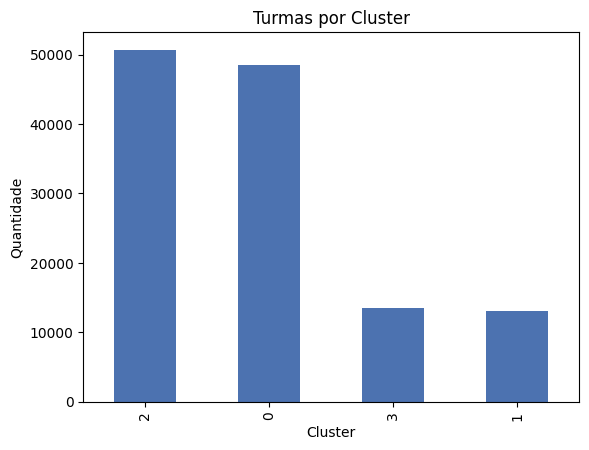

In [5]:
import matplotlib.pyplot as plt

cluster_counts = df['cluster'].value_counts().sort_values(ascending=False)
cluster_counts.plot(kind='bar', color='#4C72B0')
plt.title('Turmas por Cluster')
plt.xlabel('Cluster')
plt.ylabel('Quantidade')
plt.show()

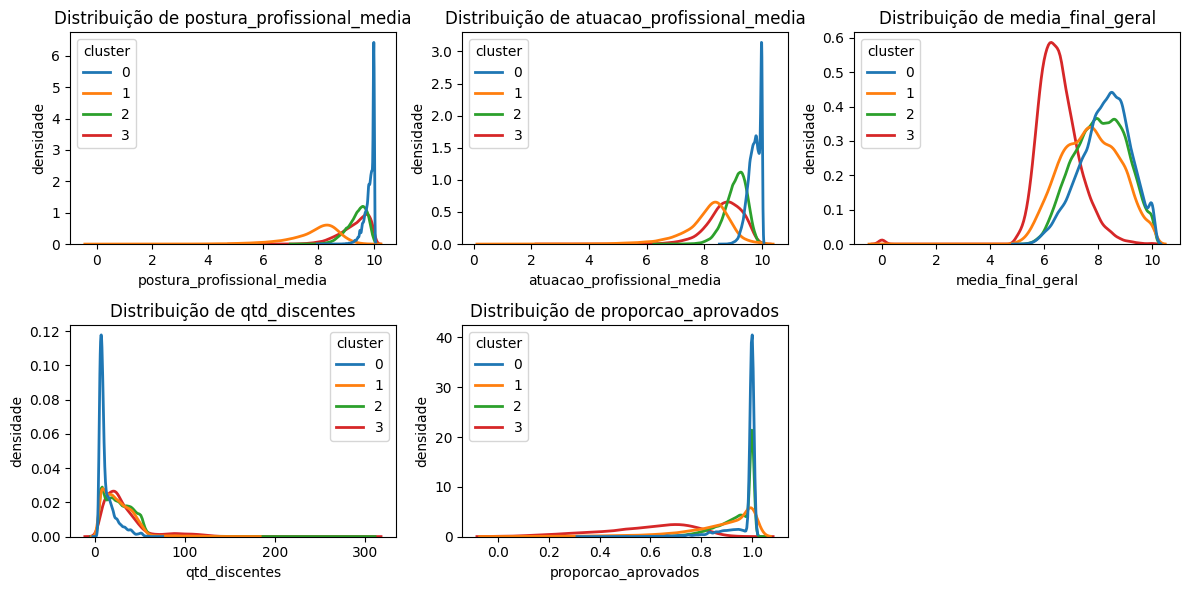

In [24]:
import seaborn as sns

numeric_cols = [
    'postura_profissional_media',
    'atuacao_profissional_media',
    'media_final_geral',
    'qtd_discentes',
    'proporcao_aprovados',
]

n_cols = 3
n_rows = -(-len(numeric_cols) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 3 * n_rows), sharex=False)
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.kdeplot(
        data=df,
        x=col,
        hue='cluster',
        common_norm=False,
        fill=False,
        linewidth=2,
        ax=ax,
        palette='tab10'
    )
    ax.set_title(f'Distribuição de {col}')
    ax.set_ylabel('densidade')

for ax in axes[len(numeric_cols):]:
    ax.axis('off')

plt.tight_layout()
plt.show()


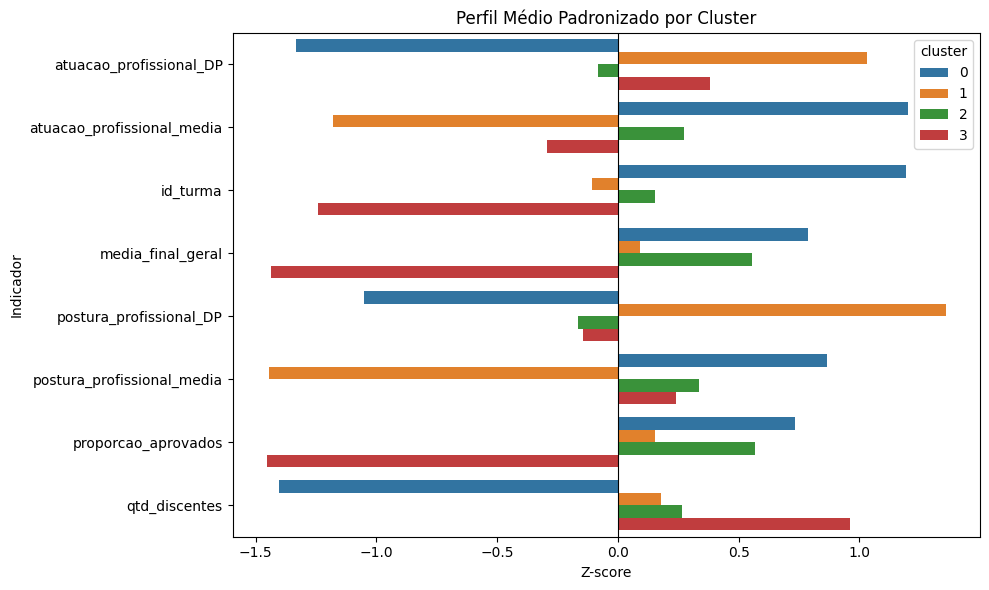

In [12]:
# ...existing code...
z_mean = (
    mean_metrics.assign(cluster=lambda d: d['cluster'].astype(str))
    .groupby(['cluster', 'Indicador'])['valor']
    .mean()
    .unstack()
    .pipe(lambda d: (d - d.mean()) / d.std())
    .stack()
    .reset_index(name='z')
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=z_mean,
    x='z',
    y='Indicador',
    hue='cluster',
    orient='h',
    palette='tab10'
)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Perfil Médio Padronizado por Cluster')
plt.xlabel('Z-score')
plt.ylabel('Indicador')
plt.tight_layout()
plt.show()
# ...existing code...

In [18]:
metrics = df.filter(like='mean', axis=1)  # ajuste conforme a estrutura real
metrics_norm = (
    metrics
    .sub(metrics.mean(axis=1), axis=0)
    .div(metrics.std(axis=1).replace(0, 1), axis=0)
)

plt.figure(figsize=(10, 6))
sns.heatmap(metrics_norm, cmap='coolwarm', center=0, annot=True, fmt='.2f')
plt.title('Perfil Médio (Escala por Linha)')
plt.tight_layout()
plt.show()

ValueError: zero-size array to reduction operation fmin which has no identity

<Figure size 1000x600 with 0 Axes>